# Sistema de Recuperación de Información con Embeddings

**Materia:** ICCD753 Recuperación de Información 2026-A  
**Examen:** Primer Bimestre
**Nombre:** Jorge Bósquez  
**Dataset:** Rotten Tomatoes Movies and Critic Reviews Dataset

Este notebook implementa un sistema de recuperación de información que:
- carga el corpus,
- selecciona campos textuales,
- preprocesa texto,
- genera embeddings,
- recupera documentos con similitud coseno,
- ejecuta las 8 consultas obligatorias,
- muestra tablas Top-k,
- genera una tabla resumen general,
- incluye una mejora: visualización PCA de embeddings.


## 1. Instalación de librerías

Ejecuta esta celda si estás trabajando en Google Colab o si no tienes instaladas las dependencias.


In [1]:
pip install pandas numpy scikit-learn sentence-transformers matplotlib seaborn nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importación de librerías

In [2]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

pd.set_option("display.max_colwidth", 160)

## 3. Carga del corpus

Coloca los archivos CSV del dataset en una carpeta llamada `data`.

Archivos esperados:
- `data/rotten_tomatoes_movies.csv`
- `data/rotten_tomatoes_critic_reviews.csv`

Para este sistema se usará principalmente el archivo de reseñas, porque contiene texto crítico útil para la recuperación semántica.


In [23]:
import os
import pandas as pd

DATA_DIR = "archive"

movies_path = os.path.join(DATA_DIR, "rotten_tomatoes_movies.csv")
reviews_path = os.path.join(DATA_DIR, "rotten_tomatoes_critic_reviews.csv")

# verificar existencia
if not os.path.exists(movies_path):
    raise FileNotFoundError(
        "No se encontró rotten_tomatoes_movies.csv"
    )

if not os.path.exists(reviews_path):
    raise FileNotFoundError(
        "No se encontró rotten_tomatoes_critic_reviews.csv"
    )

# cargar datasets
movies_df = pd.read_csv(movies_path)
reviews_df = pd.read_csv(reviews_path)

# MERGE
corpus_df = reviews_df.merge(
    movies_df,
    on="rotten_tomatoes_link",
    how="left"
)

# doc_id
corpus_df["doc_id"] = range(len(corpus_df))

print("Dimensiones del corpus:", corpus_df.shape)

corpus_df.head()

Dimensiones del corpus: (1130017, 30)


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content,movie_title,movie_info,...,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count,doc_id
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to ...,Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,0
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,1
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instalment.",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,2
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,"Whether audiences will get behind The Lightning Thief is hard to predict. Overall, it's an entertaining introduction to a promising new world -- but will th...",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,3
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,"What's really lacking in The Lightning Thief is a genuine sense of wonder, the same thing that brings viewers back to Hogwarts over and over again.",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. A...",...,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0,4


## 4. Exploración de columnas

In [24]:
print("Columnas disponibles:")
print(corpus_df.columns.tolist())

Columnas disponibles:
['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count', 'doc_id']


## 5. Selección de campos textuales

Se construirá un documento por cada reseña usando:
- título de la película,
- contenido de la crítica,
- nombre del crítico,
- editorial o medio, si existe.

El campo más importante es el contenido de la crítica.


In [26]:
# Ajuste flexible por si el CSV tiene nombres de columnas ligeramente distintos.
possible_title_cols = ["movie_title", "title", "movie"]
possible_review_cols = ["review_content", "review", "content", "critic_review"]
possible_critic_cols = ["critic_name", "critic", "author"]
possible_publisher_cols = ["publisher_name", "publisher", "publication"]

def find_col(df, possible_cols):
    for col in possible_cols:
        if col in df.columns:
            return col
    return None

title_col = find_col(corpus_df, possible_title_cols)
review_col = find_col(corpus_df, possible_review_cols)
critic_col = find_col(corpus_df, possible_critic_cols)
publisher_col = find_col(corpus_df, possible_publisher_cols)

print("Columna título:", title_col)
print("Columna reseña:", review_col)
print("Columna crítico:", critic_col)
print("Columna medio:", publisher_col)

if review_col is None:
    raise ValueError("No se encontró una columna de reseña. Revisa los nombres de columnas del CSV.")

# Selección de columnas necesarias desde corpus_df, NO desde reviews_df
selected_cols = [c for c in [title_col, review_col, critic_col, publisher_col, "rotten_tomatoes_link"] if c is not None]

corpus_df = corpus_df[selected_cols].copy()

# Eliminar reseñas vacías
corpus_df = corpus_df.dropna(subset=[review_col])
corpus_df = corpus_df[corpus_df[review_col].astype(str).str.strip() != ""]

# Para evitar tiempos muy largos, puedes limitar el corpus.
MAX_DOCS = 20000

if MAX_DOCS is not None and len(corpus_df) > MAX_DOCS:
    corpus_df = corpus_df.sample(MAX_DOCS, random_state=42).reset_index(drop=True)
else:
    corpus_df = corpus_df.reset_index(drop=True)

corpus_df["doc_id"] = corpus_df.index.astype(str)

print("Documentos usados:", len(corpus_df))
corpus_df.head()

Columna título: movie_title
Columna reseña: review_content
Columna crítico: critic_name
Columna medio: publisher_name
Documentos usados: 20000


,movie_title,review_content,critic_name,publisher_name,rotten_tomatoes_link,doc_id
0,Snatched,"It's predictable stuff for the most part, and the jokes thin out half way through, but Schumer and Hawn are great together, and Schumer wrings every last dr...",Paul Whitington,Irish Independent,m/snatched_2017,0
1,Eden,"Though the film defines Paul's life by his relationships, Eden fails to muster the kind of emotional intensity its story dictates.",Tina Hassannia,Movie Mezzanine,m/eden_2015,1
2,Cold Fish,"Just as with Suicide Club, the deliberate weirdness and detached tone of Cold Fish may initially leave audiences befuddled, but this a sign of its complexity.",Virginie Sélavy,Electric Sheep,m/cold_fish,2
3,Bad Boys,"""Bad Boys"" misses its chance at greatness, but it's saying something that this movie had a chance. I have a notion it will stand as one of those bench-mark ...",Roger Ebert,Chicago Sun-Times,m/bad_boys_1982,3
4,Amulet,"Creepy, bloody, and flat-out weird in places, Amulet is a bold directorial debut for Garai and a disquieting reminder that getting rid of the past is never ...",Alissa Wilkinson,Vox,m/amulet,4


## 6. Preprocesamiento

Pipeline obligatorio:
- conversión a minúsculas,
- eliminación de signos de puntuación,
- eliminación de espacios redundantes.

También se normaliza texto vacío para evitar errores.


In [27]:
import re
import string

def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

def build_document(row):

    parts = []

    # título película
    if title_col is not None:
        parts.append(f"Movie title: {row[title_col]}")

    # review
    parts.append(f"Review: {row[review_col]}")

    # critic
    if critic_col is not None:
        parts.append(f"Critic: {row[critic_col]}")

    # publisher
    if publisher_col is not None:
        parts.append(f"Publisher: {row[publisher_col]}")

    return " ".join([str(p) for p in parts if pd.notna(p)])

# construir documentos
corpus_df["raw_text"] = corpus_df.apply(build_document, axis=1)

# preprocesamiento
corpus_df["processed_text"] = corpus_df["raw_text"].apply(preprocess_text)

# visualizar
corpus_df[[
    "doc_id",
    title_col,
    "processed_text",
    review_col
]].head()

,doc_id,movie_title,processed_text,review_content
0,0,Snatched,movie title snatched review its predictable stuff for the most part and the jokes thin out half way through but schumer and hawn are great together and schu...,"It's predictable stuff for the most part, and the jokes thin out half way through, but Schumer and Hawn are great together, and Schumer wrings every last dr..."
1,1,Eden,movie title eden review though the film defines pauls life by his relationships eden fails to muster the kind of emotional intensity its story dictates crit...,"Though the film defines Paul's life by his relationships, Eden fails to muster the kind of emotional intensity its story dictates."
2,2,Cold Fish,movie title cold fish review just as with suicide club the deliberate weirdness and detached tone of cold fish may initially leave audiences befuddled but t...,"Just as with Suicide Club, the deliberate weirdness and detached tone of Cold Fish may initially leave audiences befuddled, but this a sign of its complexity."
3,3,Bad Boys,movie title bad boys review bad boys misses its chance at greatness but its saying something that this movie had a chance i have a notion it will stand as o...,"""Bad Boys"" misses its chance at greatness, but it's saying something that this movie had a chance. I have a notion it will stand as one of those bench-mark ..."
4,4,Amulet,movie title amulet review creepy bloody and flatout weird in places amulet is a bold directorial debut for garai and a disquieting reminder that getting rid...,"Creepy, bloody, and flat-out weird in places, Amulet is a bold directorial debut for Garai and a disquieting reminder that getting rid of the past is never ..."


## 7. Generación de embeddings

Se utiliza el modelo `all-MiniLM-L6-v2` de Sentence Transformers, porque es liviano, rápido y adecuado para similitud semántica.

Se guardan los embeddings en caché para evitar recalcularlos cada vez.


In [28]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDINGS_CACHE = "embeddings_rotten_tomatoes.npy"

model = SentenceTransformer(MODEL_NAME)

documents = corpus_df["processed_text"].tolist()

if os.path.exists(EMBEDDINGS_CACHE):
    doc_embeddings = np.load(EMBEDDINGS_CACHE)
    print("Embeddings cargados desde caché:", doc_embeddings.shape)
else:
    doc_embeddings = model.encode(
        documents,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMBEDDINGS_CACHE, doc_embeddings)
    print("Embeddings generados y guardados:", doc_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings cargados desde caché: (20000, 384)


## 8. Función de recuperación con similitud coseno

Para cada consulta:
1. se preprocesa el texto,
2. se genera su embedding,
3. se calcula similitud coseno contra todos los documentos,
4. se devuelven los Top-k documentos ordenados.


In [30]:
def search_documents(query, top_k=10):
    processed_query = preprocess_text(query)

    query_embedding = model.encode(
        [processed_query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        title = corpus_df.iloc[idx][title_col] if title_col is not None else "Sin título"
        review_text = corpus_df.iloc[idx][review_col]
        fragment = str(review_text)[:300] + "..." if len(str(review_text)) > 300 else str(review_text)

        results.append({
            "Ranking": rank,
            "ID documento": corpus_df.iloc[idx]["doc_id"],
            "Título película": title,
            "Fragmento de texto": fragment,
            "Similitud": round(float(similarities[idx]), 4)
        })

    return pd.DataFrame(results)

## 9. Prueba rápida del sistema

In [31]:
search_documents("science fiction movie with advanced technology", top_k=5)

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,4854,After Earth,"This is one of those movies where you suspect that more thought was given to coining cool, futuristic names than to plot development.",0.5118
1,2,15536,Big Hero 6,"a terrific film in its first half, where screenwriters...have rejiggered the characters into a bunch of science and engineering geeks, but once its super he...",0.5004
2,3,5853,L.A. Confidential,"The story is so complicated that the movie can't quite make it clear, but the picture has impressive energy and high-intensity performances from Kevin Space...",0.4922
3,4,4739,Moon,"This excellent little science fiction film is a welcome throwback to an earlier era, when filmmakers used the canvas afforded by outer space and/or the futu...",0.4849
4,5,1017,Elysium,"This is a big budget science fiction film with some good special effects and plenty of action. It is not the film it should have been, given the talent and ...",0.4815


## 10. Benchmark de consultas obligatorias

In [32]:
queries = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

TOP_K = 10
all_results = {}

for qid, query in queries.items():
    print("=" * 100)
    print(f"{qid}: {query}")
    print("=" * 100)

    result_df = search_documents(query, top_k=TOP_K)
    all_results[qid] = result_df

    display(result_df)

Q1: science fiction movie with advanced technology


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,4854,After Earth,"This is one of those movies where you suspect that more thought was given to coining cool, futuristic names than to plot development.",0.5118
1,2,15536,Big Hero 6,"a terrific film in its first half, where screenwriters...have rejiggered the characters into a bunch of science and engineering geeks, but once its super he...",0.5004
2,3,5853,L.A. Confidential,"The story is so complicated that the movie can't quite make it clear, but the picture has impressive energy and high-intensity performances from Kevin Space...",0.4922
3,4,4739,Moon,"This excellent little science fiction film is a welcome throwback to an earlier era, when filmmakers used the canvas afforded by outer space and/or the futu...",0.4849
4,5,1017,Elysium,"This is a big budget science fiction film with some good special effects and plenty of action. It is not the film it should have been, given the talent and ...",0.4815
5,6,4656,Upgrade,Upgrade is a future-shock action horror film sure to keep fans of high intensity science fiction happy.,0.4704
6,7,19947,Rogue One: A Star Wars Story,"This off-shoot is a heck of a fun science-fiction film, and the last third of the movie is a wild, epic battle.",0.4698
7,8,18691,The Divergent Series: Allegiant,This penultimate installment in the dour dystopian franchise offers stronger visual effects and more thought-provoking biopunk notions about genetic enginee...,0.4612
8,9,16099,Oblivion,"You could do a lot worse than this movie, that is clearly trying to bring the many classics and best of science fiction together with new ideas... gorgeous ...",0.4574
9,10,413,Ghost in the Shell,"Certainly, the film's futuristic production design is a welcome and constant marvel. However, just another story of robotics melding with humans grows old q...",0.4502


Q2: romantic story with emotional relationships


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,11203,God's Own Country,A raw and affecting love story teeming with honesty and emotion.,0.5727
1,2,19085,Wicker Park,An elegant tale of romantic obsession weighed down by a needlessly convoluted plot that yields far more confusion than psychological suspense.,0.5108
2,3,7323,The Light Between Oceans,"An emotionally rich romantic thriller about marriage, parenting, and the spiritual choices that sometimes come with both.",0.5037
3,4,8816,Animals,"The couple's doomed romance feels familiar from numerous other films about addiction, and the movie is downright bad whenever it aspires to visual poetry.",0.5012
4,5,15449,Amour,"This is an unforgettable love story set at the close of day, as tragic and beautiful in its way as ""Tristan und Isolde,"" and a portrait of the impossible be...",0.4962
5,6,13598,She Dies Tomorrow,"Interpretations of romantic relationships, American grandeur, and mental health would all be understandable here, and it would be reductive to dismiss other...",0.4900
6,7,9020,Realive,"A film that unfolds in the form of a science fiction film with moral aspirations that, in essence, is configured as a romantic love story. [Full review in S...",0.4886
7,8,30,Something's Gotta Give,"A film for adults and about adults, a charming, touching story that explores a romantic relationship not between a Maxim girl and the latest hunk, but two p...",0.4826
8,9,1700,Professor Marston & The Wonder Women,"What's so surprising is how [Angela] Robinson, who scripts as well as directs, makes this into a mature love story between three consenting adults pushing p...",0.4819
9,10,16148,The New Romantic,"The New Romantic follows a very familiar arc, but the path is certainly a pleasant one, thanks to Barden's naturally ebullient performance.",0.4763


Q3: action movie with intense fight scenes


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,18348,Night Moves,The actors give down-to-earth but emotionally charged performances distinguished by a subsurface simmer that sometimes intensifies into a slow boil.,0.5976
1,2,19439,Evil Angels (A Cry in the Dark),"Streep and Sam Neill put in convincing and consistent performances in roles that appear unsympathetic, and don't offer the typical ingredients that can allo...",0.5492
2,3,14744,Little Women,"It is a delight for anyone who appreciates genuine emotion, insight, and beautiful filmmaking.",0.5173
3,4,12264,Disgrace,"An unfocused and contrived drama that lacks a palpable emotional core, but John Malkovich's raw performance makes it at least marginally engaging.",0.4927
4,5,7006,Mission: Impossible - Fallout,"This is top-tier action filmmaking, the kind of no-holds-barred, balls-to-the-wall extravaganza that manages to root its spectacle in actual human emotion.",0.4878
5,6,10816,Mother Of George,"Oddly, the gradual pacing, with scenes that stress the pace of chill human interaction over narrative thrust, helps make the third act more powerful: The ge...",0.4876
6,7,5480,Legend of the Guardians: The Owls of Ga'Hoole,"How come the most genuinely affecting, emotional movie of the year is about animated owls?",0.4831
7,8,12566,The Best Years of Our Lives,All three of the leading actors do a great job. You empathize with each one of them for different reasons. They put a human face on the returning soldiers a...,0.4813
8,9,12033,The Journey,"Although narrative contrivances seem to oversimplify the specifics, both lead actors bring depth and complexity to their roles.",0.4793
9,10,800,28 Weeks Later...,"Its putative emotional centerpiece - a sequence involving a mass escape - is a piece of cheap, empty theater, exacerbated by illogical staging.",0.4772


Q7: predictable plot but entertaining experience


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,12287,Premium Rush,"It's a good thing that adrenaline tends to short-circuit logical thinking; the plot is mostly nonsensical, but you'll be too thrilled by the literal twists ...",0.5913
1,2,8529,Invasion of the Body Snatchers,"Very entertaining, and despite the by now over familiar-plot, pleasantly suspenseful.",0.5900
2,3,7892,Avatar,"if it runs out of imagination and even some credibility when it comes to the plot, well, there is still enough on the screen to qualify as entertaining eye ...",0.5836
3,4,10590,Step Up Revolution,"Fabulous dancing but a dumb plot. Even predictable isn't normally this predictable. And there's so much eye candy in this one, I was worried about getting a...",0.5757
4,5,15315,American Honey,"This coming-of-age tale is extra light on plot, but it has no shortage of energy or passion.",0.5748
5,6,16427,Regression,... an absurd procedural that never generates much suspense and takes itself way too seriously.,0.5650
6,7,4133,Valiant,A disarmingly enjoyable movie with a lively cast of characters and an action-packed plot based (very roughly!) on real-life events,0.5561
7,8,17590,Spartan,"When the suspenseful plot is ultimately unraveled, it turns out to be a cynical, cinematic riddle that makes little sense.",0.5555
8,9,18706,Brake,"It's never boring, and although some of this is flawed and kind of ridiculous, including the implausible ending, if you go along for the ride, there's fun a...",0.5542
9,10,10474,Cirque du Freak: The Vampire's Assistant,"The funny bits are amusing, the action entertaining, the themes simple, the promise of future tales tantalizing, and the overall feel of the movie is more c...",0.5539


Q8: movie praised by critics but unpopular with audiences


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,4249,Philomena,A small film that deserves a large audience.,0.6780
1,2,14796,Sherlock Holmes: A Game of Shadows,"The most disappointing film of the year: not dreadful, but falling so far from the brilliant initial film that its good points hardly matter.",0.6727
2,3,18683,Beirut,"Damn, is it good to watch a movie that expects the audience to pay attention and that doesn't pander to the least common denominator.",0.6668
3,4,6485,Payback,You can't help feeling that the movie owed its subject - and its audience - a bit more.,0.6614
4,5,2706,Carol,Holds back a bit compared to its more melodramatic predecessor. But these are small complaints about a movie containing a trio of truly extraordinary and mo...,0.6588
5,6,7228,Planet 51,"The movie as a whole isn't exactly ground-breaking, and some of the humor tanks. But it has enough action, laughs and candy-hued visuals to satisfy the targ...",0.6564
6,7,16814,Raiders of the Lost Ark,"This film was also not only the subject of my very first movie review, but also the reason why I started reading movie reviews in newspapers and paying atte...",0.6560
7,8,2867,The Disappointments Room,"Disappointments has the strange confidence of a much slicker, more decisive movie, and all of its sort-ofs don't add up to much.",0.6549
8,9,13805,Realive,... a powerful movie that leaves the viewer feeling and questioning things.,0.6540
9,10,10691,Wish You Were Here,"I walked away liking the general aesthetic of the movie and elements of it, dissatisfied with it as a whole but still impressed enough to give it a gentle r...",0.6518


## 11. Tabla resumen general

Se muestra el mejor resultado Top-1 de cada consulta.


In [34]:
summary_rows = []

for qid, query in queries.items():
    top1 = all_results[qid].iloc[0]
    summary_rows.append({
        "ID Consulta": qid,
        "Consulta": f"{qid}: {query}",
        "Documento Top-1": top1["ID documento"],
        "Título película": top1["Título película"],
        "Similitud": top1["Similitud"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,ID Consulta,Consulta,Documento Top-1,Título película,Similitud
0,Q1,Q1: science fiction movie with advanced technology,4854,After Earth,0.5118
1,Q2,Q2: romantic story with emotional relationships,11203,God's Own Country,0.5727
2,Q3,Q3: action movie with intense fight scenes,11229,Tae Guk Gi: The Brotherhood of War,0.5208
3,Q4,Q4: horror film that creates fear and suspense,12273,The Descent,0.7658
4,Q5,Q5: visually impressive movie with weak storyline,3245,Immortals,0.5868
5,Q6,Q6: emotionally moving performance by the lead actor,18348,Night Moves,0.5976
6,Q7,Q7: predictable plot but entertaining experience,12287,Premium Rush,0.5913
7,Q8,Q8: movie praised by critics but unpopular with audiences,4249,Philomena,0.6780


## 12. Desafío de excelencia: visualización de embeddings con PCA

Como mejora adicional, se visualizan documentos y consultas en 2 dimensiones usando PCA.
Esto permite observar la cercanía aproximada entre las consultas y los documentos recuperados.


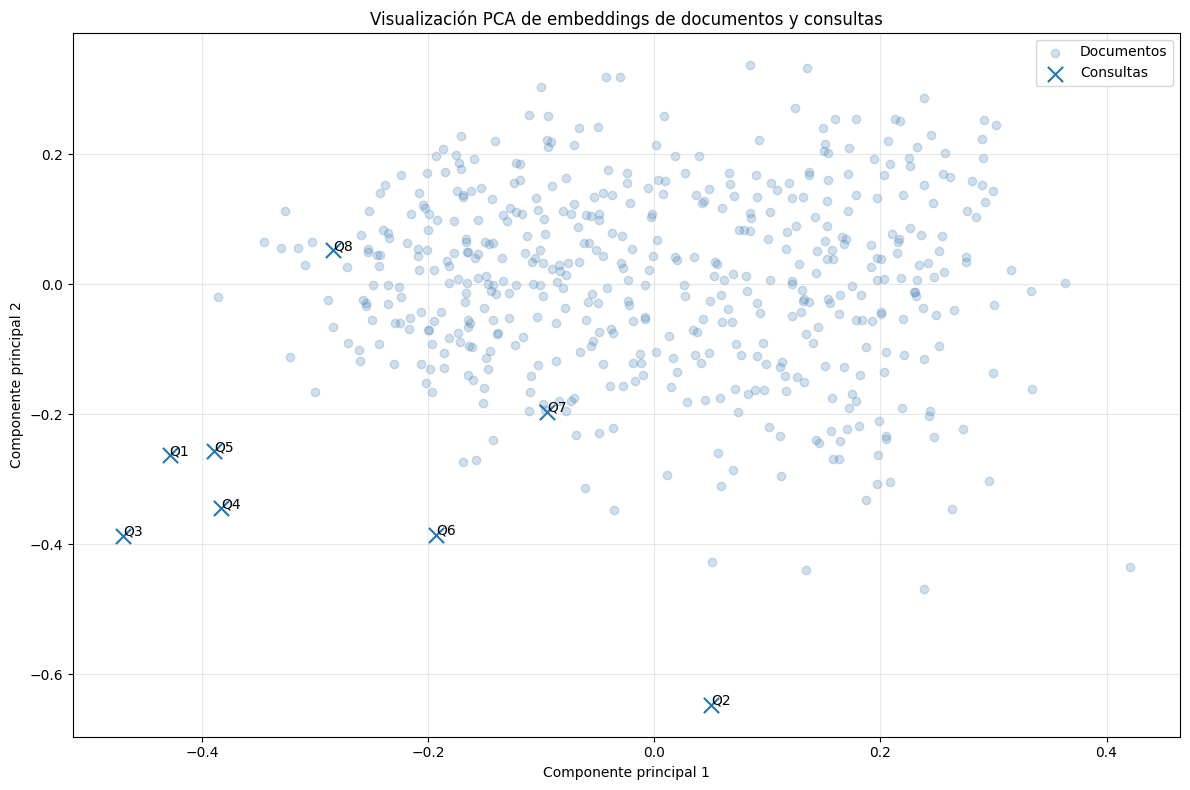

In [37]:
# Tomamos una muestra de documentos para visualizar.
N_VIS = min(500, len(corpus_df))
sample_indices = np.random.RandomState(42).choice(len(corpus_df), size=N_VIS, replace=False)

sample_embeddings = doc_embeddings[sample_indices]
sample_titles = corpus_df.loc[sample_indices, title_col].astype(str).tolist() if title_col is not None else ["Documento"] * N_VIS

query_texts = list(queries.values())
query_embeddings = model.encode(
    [preprocess_text(q) for q in query_texts],
    convert_to_numpy=True,
    normalize_embeddings=True
)

combined_embeddings = np.vstack([sample_embeddings, query_embeddings])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined_embeddings)

doc_coords = coords[:N_VIS]
query_coords = coords[N_VIS:]

plt.figure(figsize=(12, 8))
plt.scatter(doc_coords[:, 0], doc_coords[:, 1], alpha=0.25,c="steelblue", label="Documentos")

plt.scatter(query_coords[:, 0], query_coords[:, 1], marker="x", s=120, label="Consultas")

for i, qid in enumerate(queries.keys()):
    plt.annotate(qid, (query_coords[i, 0], query_coords[i, 1]))

plt.title("Visualización PCA de embeddings de documentos y consultas")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Exportar resultados a CSV

Esta celda guarda:
- resultados Top-k por consulta,
- tabla resumen general.


In [38]:
os.makedirs("resultados", exist_ok=True)

for qid, result_df in all_results.items():
    result_df.to_csv(f"resultados/{qid}_topk.csv", index=False, encoding="utf-8-sig")

summary_df.to_csv("resultados/resumen_general.csv", index=False, encoding="utf-8-sig")

print("Resultados exportados en la carpeta resultados/")

Resultados exportados en la carpeta resultados/


## 14. Conclusión

El sistema implementado permite recuperar documentos del corpus Rotten Tomatoes usando embeddings semánticos y similitud coseno.  
Las consultas obligatorias fueron ejecutadas y se presentaron tablas Top-k junto con una tabla resumen general.  
Además, se añadió una mejora de excelencia mediante visualización PCA de embeddings.
